# Relational Reasoning Benchmark — Report

Loads `results/summary.csv` and `results/raw/<prompt_variant>/` and renders per-variant × per-model accuracy (broken out by prompt variant: `cot` vs `no_cot`), scale-test curve, error-type breakdown, and per-problem drill-down. Rerun all cells after each benchmark run.

In [31]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
RESULTS = REPO / "results"
RAW = RESULTS / "raw"

summary = pd.read_csv(RESULTS / "summary.csv")
summary.head()

,prompt_variant,model,variant,problem_id,n_samples,n_correct,accuracy,n_feature_match,n_positional_match,n_other,n_parse_error,mean_output_tokens,mean_latency_ms,mean_latency_ms_correct,mean_latency_ms_error
0,cot,claude-opus-4-7,adversarial,adversarial_01,10,10,1.0,0,0,0,0,271.8,5418.4,NaN,NaN
1,cot,claude-opus-4-7,baseline,baseline_01,10,10,1.0,0,0,0,0,140.1,3052.4,NaN,NaN
2,cot,claude-opus-4-7,adversarial,adversarial_00,10,10,1.0,0,0,0,0,221.3,4613.3,NaN,NaN
3,cot,claude-opus-4-7,baseline,baseline_00,10,10,1.0,0,0,0,0,179.0,3765.6,NaN,NaN
4,cot,claude-opus-4-7,feature_misleading,feature_misleading_00,10,10,1.0,0,0,0,0,176.2,3490.9,NaN,NaN


## Accuracy by variant and model

In [32]:
pivot = (
    summary.groupby(["prompt_variant", "variant", "model"], as_index=False)
    .agg(accuracy=("accuracy", "mean"),
         se=("accuracy", lambda x: x.std(ddof=1) / (len(x) ** 0.5)),
         n_instances=("problem_id", "nunique"))
)
display_pivot = (
    pivot.pivot(index=["prompt_variant", "variant"], columns="model", values="accuracy")
    .round(3)
)
display_pivot

model                               claude-haiku-4-5-20251001  \
prompt_variant  variant                                         
cot             adversarial                              0.08   
                baseline                                 0.16   
                control                                  0.00   
                cross_domain                             0.00   
                feature_misleading                       0.20   
                scale                                    0.58   
graphical_model cross_domain                             0.96   

model                               claude-opus-4-7  claude-sonnet-4-6  \
prompt_variant  variant                                                  
cot             adversarial                    1.00               0.98   
                baseline                       0.98               1.00   
                control                        0.00               0.00   
                cross_domain                   0.02               0.00   
                feature_misleading             1.00               0.90   
                scale                          0.76               0.92   
graphical_model cross_domain                   1.00               1.00   

model                               lmstudio:google/gemma-3n-e4b  
prompt_variant  variant                                           
cot             adversarial                                0.137  
                baseline                                   0.651  
                control                                    0.000  
                cross_domain                               0.000  
                feature_misleading                         0.500  
                scale                                      0.180  
graphical_model cross_domain                               1.000

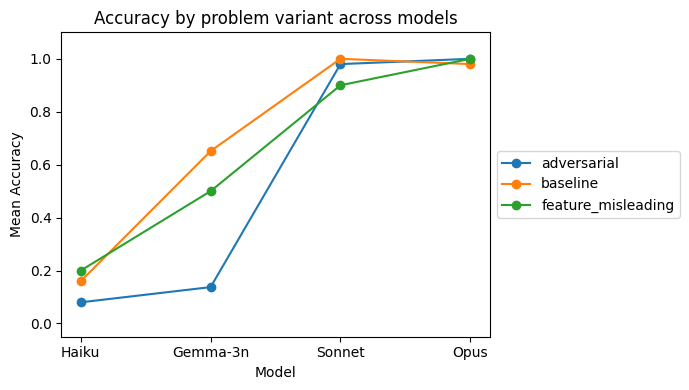

In [33]:
model_order = [
    "claude-haiku-4-5-20251001",
    "lmstudio:google/gemma-3n-e4b",
    "claude-sonnet-4-6",
    "claude-opus-4-7",
]
model_labels = ["Haiku", "Gemma-3n", "Sonnet", "Opus"]

# Mean accuracy per (variant, model), averaged over problem instances
acc = (
    summary[~summary["variant"].isin(["control", "scale", "cross_domain"])]
    .groupby(["variant", "model"], as_index=False)["accuracy"]
    .mean()
)

fig, ax = plt.subplots(figsize=(7, 4))
for variant, grp in acc.groupby("variant"):
    grp = grp.set_index("model").reindex(model_order)
    ax.plot(
        model_labels, grp["accuracy"].values,
        marker="o", label=variant,
    )

ax.set_xlabel("Model")
ax.set_ylabel("Mean Accuracy")
ax.set_ylim(-0.05, 1.1)
ax.set_title("Accuracy by problem variant across models")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
fig.tight_layout()
plt.show()

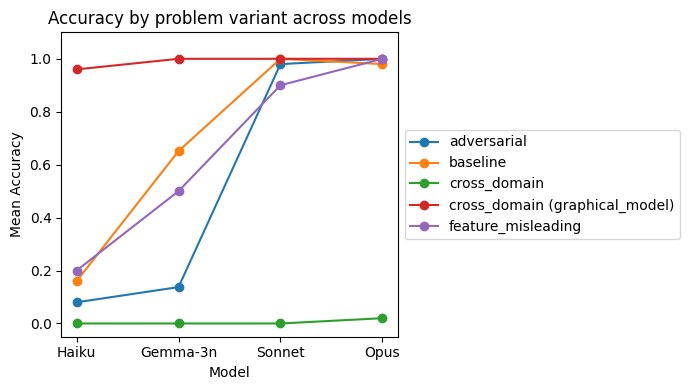

In [34]:
# Mean accuracy per (variant, model), averaged over problem instances
acc = (
    summary[~summary["variant"].isin(["control", "scale"]) & (summary["prompt_variant"] != "graphical_model")]
    .groupby(["variant", "model"], as_index=False)["accuracy"]
    .mean()
)

# Add cross_domain from graphical_model prompt variant as a separate line
acc_gm = (
    summary[(summary["variant"] == "cross_domain") & (summary["prompt_variant"] == "graphical_model")]
    .groupby(["variant", "model"], as_index=False)["accuracy"]
    .mean()
)
acc_gm["variant"] = "cross_domain (graphical_model)"
acc = pd.concat([acc, acc_gm], ignore_index=True)

fig, ax = plt.subplots(figsize=(7, 4))
for variant, grp in acc.groupby("variant"):
    grp = grp.set_index("model").reindex(model_order)
    ax.plot(
        model_labels, grp["accuracy"].values,
        marker="o", label=variant,
    )

ax.set_xlabel("Model")
ax.set_ylabel("Mean Accuracy")
ax.set_ylim(-0.05, 1.1)
ax.set_title("Accuracy by problem variant across models")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
fig.tight_layout()
plt.show()

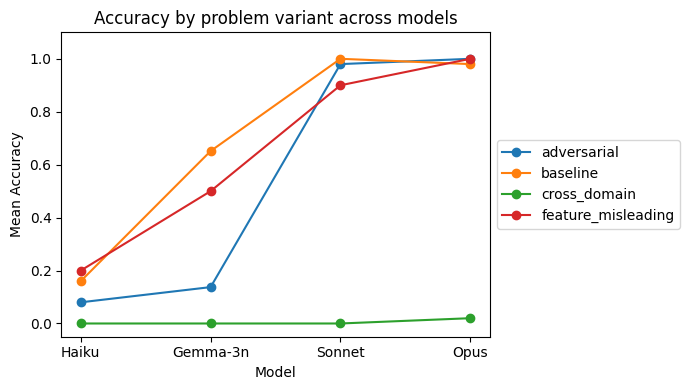

In [35]:
# Mean accuracy per (variant, model), averaged over problem instances
acc = (
    summary[~summary["variant"].isin(["control", "scale"]) & (summary["prompt_variant"] != "graphical_model")]
    .groupby(["variant", "model"], as_index=False)["accuracy"]
    .mean()
)

fig, ax = plt.subplots(figsize=(7, 4))
for variant, grp in acc.groupby("variant"):
    grp = grp.set_index("model").reindex(model_order)
    ax.plot(
        model_labels, grp["accuracy"].values,
        marker="o", label=variant,
    )

ax.set_xlabel("Model")
ax.set_ylabel("Mean Accuracy")
ax.set_ylim(-0.05, 1.1)
ax.set_title("Accuracy by problem variant across models")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
fig.tight_layout()
plt.show()

## Scale-test curve

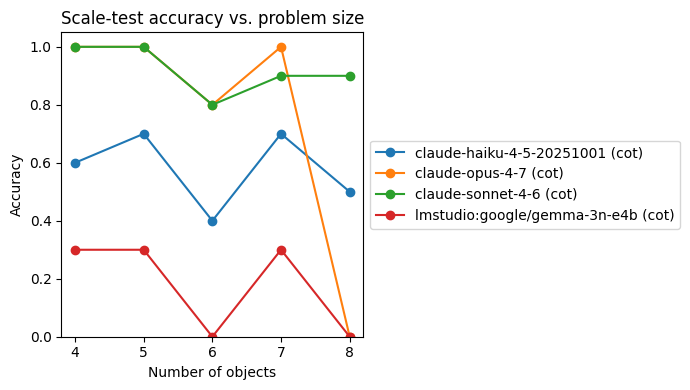

In [36]:
scale_rows = summary[summary["variant"] == "scale"].copy()
# Extract n_objects from the problem JSON.
def _n_objects(problem_id):
    path = REPO / "problems" / f"{problem_id}.json"
    return json.loads(path.read_text())["metadata"]["n_objects"]

scale_rows["n_objects"] = scale_rows["problem_id"].map(_n_objects)

# Solid = cot, dashed = no_cot.
linestyle_for = {"cot": "-", "no_cot": "--"}

fig, ax = plt.subplots(figsize=(7, 4))
for (model, pv), g in scale_rows.groupby(["model", "prompt_variant"]):
    g = g.sort_values("n_objects")
    ax.plot(
        g["n_objects"], g["accuracy"],
        marker="o", linestyle=linestyle_for.get(pv, "-"),
        label=f"{model} ({pv})",
    )
ax.set_xlabel("Number of objects")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)
ax.set_title("Scale-test accuracy vs. problem size")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
fig.tight_layout()
plt.show()

## Error-type breakdown

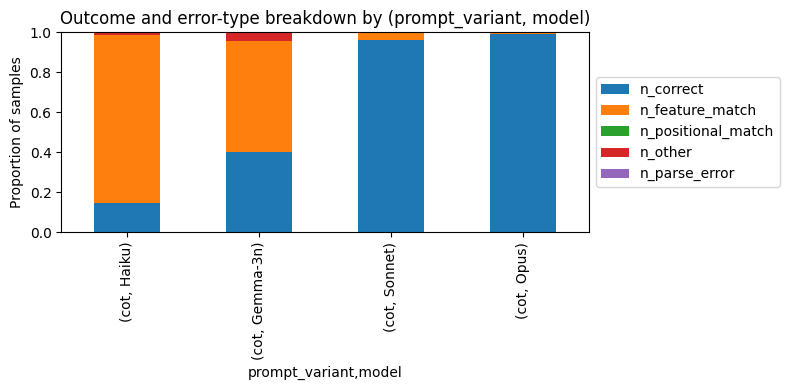

In [37]:
short_model = {
    "claude-haiku-4-5-20251001": "Haiku",
    "lmstudio:google/gemma-3n-e4b": "Gemma-3n",
    "claude-sonnet-4-6": "Sonnet",
    "claude-opus-4-7": "Opus",
}
model_order_short = ["Haiku", "Gemma-3n", "Sonnet", "Opus"]

error_cols = ["n_correct", "n_feature_match", "n_positional_match", "n_other", "n_parse_error"]
by_group = summary[~summary["variant"].isin(["control", "scale", "cross_domain"])].groupby(["prompt_variant", "model"])[error_cols].sum()
by_group = by_group.rename(index=short_model, level="model")
by_group = by_group.reindex(model_order_short, level="model")
# Normalize to proportions of samples.
by_group_pct = by_group.div(by_group.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
by_group_pct.plot(kind="bar", stacked=True, ax=ax)
ax.set_ylabel("Proportion of samples")
ax.set_title("Outcome and error-type breakdown by (prompt_variant, model)")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
fig.tight_layout()
plt.show()

## Per-problem drill-down

In [38]:
drill = summary.sort_values(["variant", "problem_id", "prompt_variant", "model"])
drill[["prompt_variant", "model", "variant", "problem_id", "accuracy",
       "n_feature_match", "n_positional_match", "n_parse_error"]]

,prompt_variant,model,variant,problem_id,accuracy,n_feature_match,n_positional_match,n_parse_error
27,cot,claude-haiku-4-5-20251001,adversarial,adversarial_00,0.200000,8,0,0
2,cot,claude-opus-4-7,adversarial,adversarial_00,1.000000,0,0,0
52,cot,claude-sonnet-4-6,adversarial,adversarial_00,1.000000,0,0,0
78,cot,lmstudio:google/gemma-3n-e4b,adversarial,adversarial_00,0.333333,10,0,0
25,cot,claude-haiku-4-5-20251001,adversarial,adversarial_01,0.100000,8,0,0
...,...,...,...,...,...,...,...,...
83,cot,lmstudio:google/gemma-3n-e4b,scale,scale_03,0.300000,4,0,1
32,cot,claude-haiku-4-5-20251001,scale,scale_04,0.500000,5,0,0
7,cot,claude-opus-4-7,scale,scale_04,0.000000,10,0,0
57,cot,claude-sonnet-4-6,scale,scale_04,0.900000,0,0,0


## Inspect a single response

Change `prompt_variant`, `model_id`, `problem_id`, and `sample_n` below to view a specific model output.

In [39]:
prompt_variant = "cot"
model_id = "claude-opus-4-7"
problem_id = "baseline_01"
sample_n = 0

path = RAW / prompt_variant / model_id / problem_id / f"sample_{sample_n}.json"
rec = json.loads(path.read_text())
print("=== PROMPT ===\n")
print(rec["prompt"])
print("\n=== RESPONSE ===\n")
print(rec["response_text"])
print("\n=== SCORE ===")
print({k: rec[k] for k in ["is_correct", "error_type", "parsed_answer", "correct_answer"]})

=== PROMPT ===

I'm going to describe two scenarios. In the memory scenario, a novel object called a skiv has a property: it can be activated by pressing the button at a specific position on it. Your job is to figure out which object in the perception scenario is the skiv-analog, and therefore which button on it activates it.

Memory scenario: There are three objects on a table: a hask, a prit, and a skiv. The hask is underneath the prit. The prit is to-the-left-of the skiv. The hask has a cyan button on top, a pink button on side, and a orange button on bottom. The prit has a black button on top, a blue button on side, and a red button on bottom. The skiv has a brown button on top, a green button on side, and a purple button on bottom. Pressing the button on the top of the skiv activates it.

Perception scenario: There are three objects on a shelf: a glim, a pell, and a drog. The glim is underneath the pell. The pell is to-the-left-of the drog. The glim has a brown button on top, a gr

In [40]:
prompt_variant = "cot"
model_id = "claude-opus-4-7"
problem_id = "cross_domain_00"
sample_n = 0

path = RAW / prompt_variant / model_id / problem_id / f"sample_{sample_n}.json"
rec = json.loads(path.read_text())
print("=== PROMPT ===\n")
print(rec["prompt"])
print("\n=== RESPONSE ===\n")
print(rec["response_text"])
print("\n=== SCORE ===")
print({k: rec[k] for k in ["is_correct", "error_type", "parsed_answer", "correct_answer"]})

=== PROMPT ===

I'm going to describe two scenarios. In the memory scenario, a novel employee called a skiv has a property: it can be activated by assigning the specialty at a specific position on it. Your job is to figure out which plant in the perception scenario is the skiv-analog, and therefore which leaf on it activates it.

Memory scenario: There are three employees in an organization: a skiv, a tunk, and a drog. The skiv reports-to the tunk. The tunk sits-beside the drog. The skiv has a yellow color-coded specialty on top, a cyan color-coded specialty on side, and a brown color-coded specialty on bottom. The tunk has a orange color-coded specialty on top, a red color-coded specialty on side, and a black color-coded specialty on bottom. The drog has a green color-coded specialty on top, a purple color-coded specialty on side, and a pink color-coded specialty on bottom. Assigning the specialty at the bottom position of the skiv activates it.

Perception scenario: There are three p